# 01 — Exploratory Data Analysis (EDA)

This notebook follows the roadmap in `crime_prediction_architecture.md`.

**Dataset**: US Homicide Reports

**Baseline target (recommended)**: `Crime Solved` (Yes/No)


In [12]:
# Setup + load dataset
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve project root (works when running from workspace root or /notebooks)
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))

RAW_CSV = PROJECT_ROOT / "data" / "raw" / "database.csv"

df = pd.read_csv(RAW_CSV, low_memory=False)

print("Project root:", PROJECT_ROOT)
print("Raw CSV:", RAW_CSV)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Project root: C:\Users\Wassim Rahali\Desktop\Crime IA
Raw CSV: C:\Users\Wassim Rahali\Desktop\Crime IA\data\raw\database.csv
Shape: (638454, 24)
Columns: ['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']


,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [15]:
# Data types + missing values
print(df.info())

missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Record ID              638454 non-null  int64
 1   Agency Code            638454 non-null  str  
 2   Agency Name            638454 non-null  str  
 3   Agency Type            638454 non-null  str  
 4   City                   638454 non-null  str  
 5   State                  638454 non-null  str  
 6   Year                   638454 non-null  int64
 7   Month                  638454 non-null  str  
 8   Incident               638454 non-null  int64
 9   Crime Type             638454 non-null  str  
 10  Crime Solved           638454 non-null  str  
 11  Victim Sex             638454 non-null  str  
 12  Victim Age             638454 non-null  int64
 13  Victim Race            638454 non-null  str  
 14  Victim Ethnicity       638454 non-null  str  
 15  Perpetrator Sex        63845

Record ID           0.0
Agency Code         0.0
Agency Name         0.0
Agency Type         0.0
City                0.0
State               0.0
Year                0.0
Month               0.0
Incident            0.0
Crime Type          0.0
Crime Solved        0.0
Victim Sex          0.0
Victim Age          0.0
Victim Race         0.0
Victim Ethnicity    0.0
dtype: float64

Crime Solved
Yes    448172
No     190282
Name: count, dtype: int64

Normalized:
Crime Solved
Yes    0.702
No     0.298
Name: count, dtype: float64


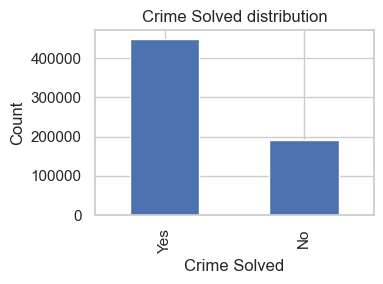

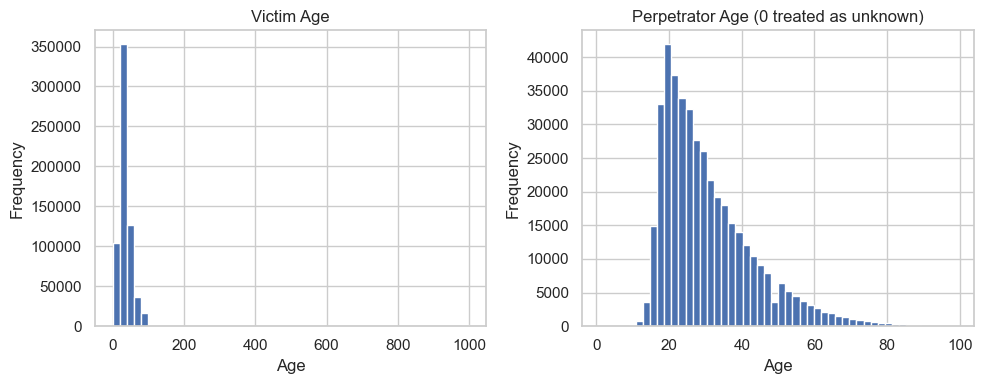

In [16]:
# Target balance (Crime Solved)
target = df["Crime Solved"].astype(str).str.strip()
vc = target.value_counts(dropna=False)
print(vc)
print("\nNormalized:")
print((vc / len(df)).round(4))

plt.figure(figsize=(4, 3))
vc.plot(kind="bar")
plt.title("Crime Solved distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Basic numeric distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.to_numeric(df["Victim Age"], errors="coerce").plot(kind="hist", bins=50, ax=axes[0])
axes[0].set_title("Victim Age")
axes[0].set_xlabel("Age")

perp_age = pd.to_numeric(df["Perpetrator Age"], errors="coerce")
perp_age = perp_age.replace(0, np.nan)
perp_age.plot(kind="hist", bins=50, ax=axes[1])
axes[1].set_title("Perpetrator Age (0 treated as unknown)")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

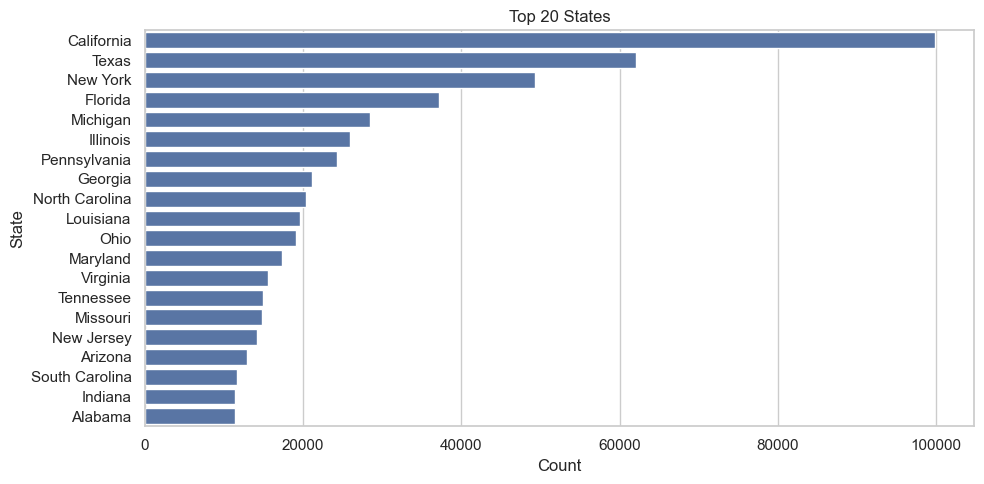

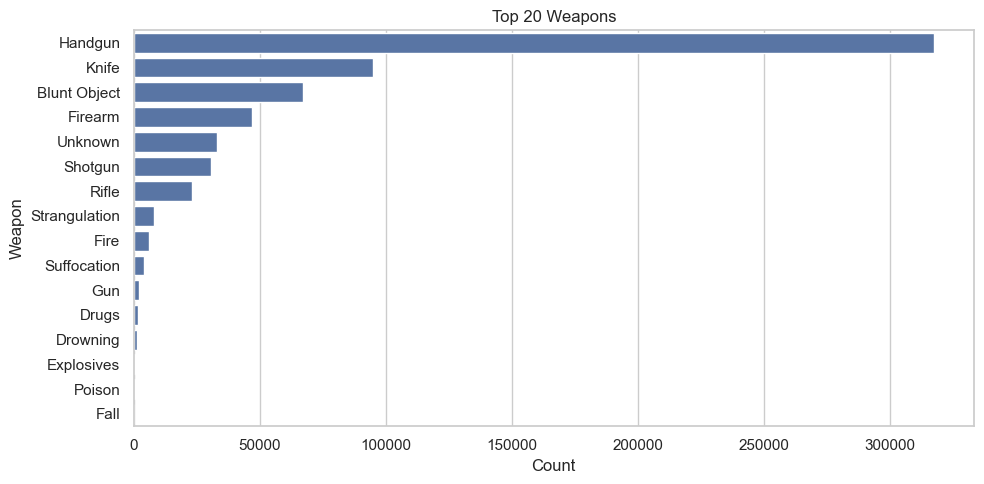

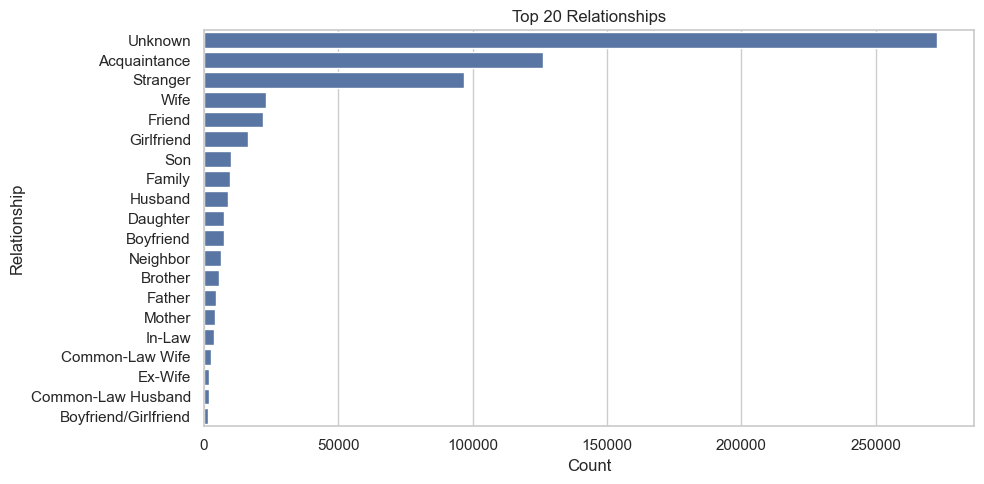

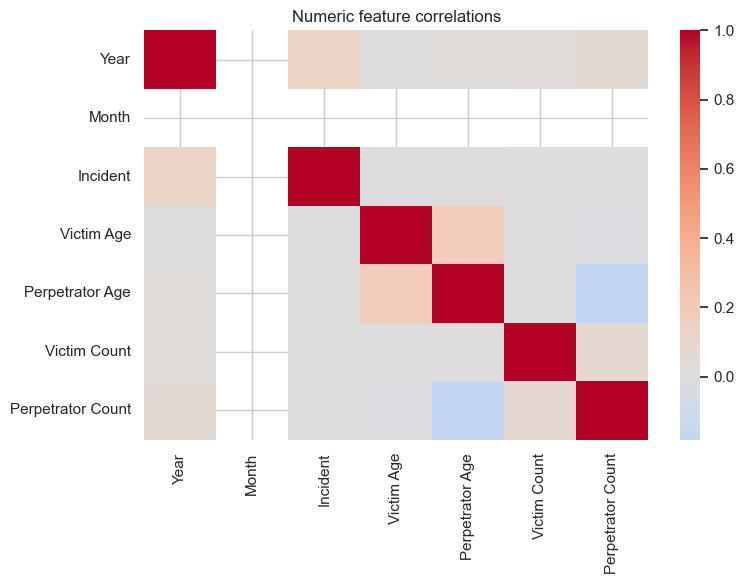

In [17]:
# Key categorical distributions (top-N)
from src.evaluate import plot_top_categories

plot_top_categories(df["State"], top_n=20, title="Top 20 States")
plot_top_categories(df["Weapon"], top_n=20, title="Top 20 Weapons")
plot_top_categories(df["Relationship"], top_n=20, title="Top 20 Relationships")

# Correlation heatmap for numeric columns
num_cols = [
    "Year",
    "Month",
    "Incident",
    "Victim Age",
    "Perpetrator Age",
    "Victim Count",
    "Perpetrator Count",
]
num_df = df[num_cols].apply(pd.to_numeric, errors="coerce").copy()
num_df["Perpetrator Age"] = num_df["Perpetrator Age"].replace(0, np.nan)

corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()

In [18]:
# Quick sanity checks for unusual values
print("Unique Crime Solved values:", df["Crime Solved"].astype(str).str.strip().unique()[:10])
print("Min/Max Victim Age:", pd.to_numeric(df["Victim Age"], errors="coerce").min(), pd.to_numeric(df["Victim Age"], errors="coerce").max())
print("Min/Max Perpetrator Age:", pd.to_numeric(df["Perpetrator Age"], errors="coerce").replace(0, np.nan).min(), pd.to_numeric(df["Perpetrator Age"], errors="coerce").replace(0, np.nan).max())

# Tip: after this EDA, run 02_preprocessing.ipynb to produce train/val/test splits.

Unique Crime Solved values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Min/Max Victim Age: 0 998
Min/Max Perpetrator Age: 1.0 99.0
